# Hypothesis Testing — Practice Notebook
### From business question to statistical conclusion

---

## What we cover today

```
Part 1 — From business question to hypothesis
Part 2 — Key concepts: H₀, H₁, errors, confidence, power
Part 3 — Test direction visualised
Part 4 — Real world example: COVID test and alpha
Part 5 — The 8-step procedure in Python
Part 6 — Practice exercises
```

The core question of the day:
> **How can we use data to test a business hypothesis?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Ready!')

Ready!


---
## Part 1 — From Business Question to Hypothesis

Before running any test in Python, you need to translate the business question
into statistics. This always follows the same four steps:

```
1. Business question  →  What are we trying to find out?
2. KPI               →  What metric captures success?
3. Metric type       →  Mean, proportion, or variance?
4. Comparison        →  One group vs benchmark? Or two groups?
```

### The three metric types and their symbols

| Metric | Symbol | Use when |
|--------|--------|----------|
| **Mean** | μ | Measuring averages — time, revenue, score |
| **Proportion** | p | Measuring rates — conversion, click rate, % users |
| **Variance** | σ² | Measuring consistency — is the process more stable? |

### The three test directions

| Business says | Direction | H₀ | H₁ |
|--------------|-----------|----|----|  
| Treatment is **higher** | One-sided right | μ_T ≤ μ_C | μ_T > μ_C |
| Treatment is **lower** | One-sided left | μ_T ≥ μ_C | μ_T < μ_C |
| Treatment is **different** | Two-sided | μ_T = μ_C | μ_T ≠ μ_C |

### Worked example — VAT checkout test

**Business hypothesis:**  
Showing VAT earlier in checkout will increase customer trust and reduce last-minute abandonment, improving checkout conversion.

| Step | Answer |
|------|--------|
| KPI | Checkout Conversion |
| Metric | Mean conversion rate |
| Comparison | Mean between two groups (Treatment vs Control) |
| Direction | Treatment should be **higher** → one-sided right |

So:
- Business hypothesis: μ_T > μ_C
- H₀: μ_T ≤ μ_C (treatment is no better — the boring default)
- H₁: μ_T > μ_C (treatment is better — what we are trying to prove)

> **Key rule:** H₀ always contains = and represents the "nothing happened" default.  
> H₁ is what you are trying to prove.

### Exercise 1 — Write the hypotheses

In [ ]:
# Scenario A — Trade Republic
# Business question: Does adding a short risk-warning message before users buy
# crypto REDUCE the average amount invested in crypto?
#
# Fill in the blanks:

metric_type_a = '___'   # hint: mean / proportion / variance
direction_a   = '___'   # hint: one-sided left / one-sided right / two-sided
H0_a = 'μ_T ___ μ_C'   # hint: which sign makes H₀ the boring default?
H1_a = 'μ_T ___ μ_C'

print('Scenario A:')
print(f'  Metric type : {metric_type_a}')
print(f'  Direction   : {direction_a}')
print(f'  H₀          : {H0_a}')
print(f'  H₁          : {H1_a}')

# ANSWER:
# metric_type_a = 'mean'
# direction_a   = 'one-sided left'  (we expect LOWER investment)
# H0_a = 'μ_T >= μ_C'
# H1_a = 'μ_T < μ_C'

In [ ]:
# Scenario B — Raisin
# Business question: Does simplifying the savings-account comparison page
# INCREASE the proportion of users who click 'Open Account'?

metric_type_b = '___'   # hint: mean / proportion / variance
direction_b   = '___'   # hint: one-sided left / one-sided right / two-sided
H0_b = 'p_T ___ p_C'
H1_b = 'p_T ___ p_C'

print('Scenario B:')
print(f'  Metric type : {metric_type_b}')
print(f'  Direction   : {direction_b}')
print(f'  H₀          : {H0_b}')
print(f'  H₁          : {H1_b}')

# ANSWER:
# metric_type_b = 'proportion'
# direction_b   = 'one-sided right'
# H0_b = 'p_T <= p_C'
# H1_b = 'p_T > p_C'

In [ ]:
# Scenario C — Delivery Hero
# Business question: Does showing estimated delivery delays earlier
# REDUCE THE VARIANCE in customer satisfaction scores?

metric_type_c = '___'   # hint: mean / proportion / variance
direction_c   = '___'   # hint: one-sided left / one-sided right / two-sided
H0_c = 'σ²_T ___ σ²_C'
H1_c = 'σ²_T ___ σ²_C'

print('Scenario C:')
print(f'  Metric type : {metric_type_c}')
print(f'  Direction   : {direction_c}')
print(f'  H₀          : {H0_c}')
print(f'  H₁          : {H1_c}')





# ANSWER:
# metric_type_c = 'variance'
# direction_c   = 'one-sided left'  (we expect LOWER variance = more consistent)
# H0_c = 'σ²_T >= σ²_C'
# H1_c = 'σ²_T < σ²_C'

---
## Part 2 — Key Concepts

### 1. H₀ and H₁

| | Meaning | Plain English |
|--|---------|---------------|
| **H₀** | Default assumption — nothing changed | "The feature does not improve conversion" |
| **H₁** | What we are trying to prove | "The feature improves conversion" |

The test looks for enough evidence to **reject H₀**.  
If we cannot reject it, we do not "accept" it — we just lack evidence against it.

---

### 2. Type I Error — False Positive (α)

A Type I error happens when the test says there IS an effect, but in reality there is none.

- Pregnancy example: not pregnant, but test says positive
- A/B test example: the feature does not work, but we conclude it works

$$\alpha = P(\text{Reject } H_0 \mid H_0 \text{ is true})$$

α = **probability of a false alarm** — usually set to 0.05

---

### 3. Confidence Level

$$\text{Confidence level} = 1 - \alpha$$

If α = 0.05 → Confidence = 95%  
Meaning: we accept a 5% risk of saying "positive" when there is actually no real effect.

> ⚠️ 95% confidence does **not** mean "there is a 95% probability the feature works."  
> It means we **control the false positive risk at 5%**.

---

### 4. Type II Error — False Negative (β)

A Type II error happens when the test says there is NO effect, but in reality there is one.

- Pregnancy example: pregnant, but test says negative
- A/B test example: the feature actually works, but we fail to detect it

$$\beta = P(\text{Fail to reject } H_0 \mid H_1 \text{ is true})$$

β = **probability of missing a real effect**

---

### 5. Power of the test

$$\text{Power} = 1 - \beta$$

Power is the probability of **correctly detecting a real effect**.  
Usually people aim for Power = 80% or 90%.

| | Avoid | Use when |
|--|-------|----------|
| **Confidence** (1−α) | False positives | Fintech credit, A/B test |
| **Power** (1−β) | False negatives | Medical test, fraud detection, safety |

---

### Why not just set α = 0?

Students often ask this. The answer is that **you cannot eliminate both errors at the same time.**

Think of it like a security alarm:

```
Very sensitive alarm (high α):  catches every real burglar
                                BUT triggers on cats, wind, shadows (many false alarms)

Very strict alarm (α → 0):      almost never false alarm
                                BUT misses real burglars too (high β, low power)
```

If you set α = 0 you are saying **"I will never reject H₀ under any circumstances."**  
That means your test is useless — you would never detect any real effect either.

| Situation | Typical α | Why |
|-----------|-----------|-----|
| Marketing A/B test | 0.05 | Missing a small improvement is acceptable |
| Medical drug trial | 0.01 | False approval could harm patients |
| Fraud detection | 0.10 | Missing real fraud is very costly |

In [ ]:
# Concept check — fill in the blanks

# Q1: If alpha = 0.05, what is the confidence level?
alpha      = 0.05
confidence = ___
print(f'Confidence level: {confidence}')

# Q2: If beta = 0.20, what is the power?
beta  = 0.20
power = ___
print(f'Power: {power}')

# Q3: Which error is worse in a medical cancer screening test?
worse_error = '___'   # hint: 'Type I' or 'Type II'
why         = '___'   # one sentence
print(f'Worse error: {worse_error}')
print(f'Why: {why}')









# ANSWERS:
# Q1: 1 - alpha = 0.95
# Q2: 1 - beta  = 0.80
# Q3: Type II — missing a real cancer is more dangerous than a false alarm

Confidence level: 
Power: 
Worse error: ___
Why: ___


---
## Part 3 — Test Direction Visualised

The rejection region — where we reject H₀ — changes depending on the direction of H₁.  
This is the most important visual to understand before running any test.

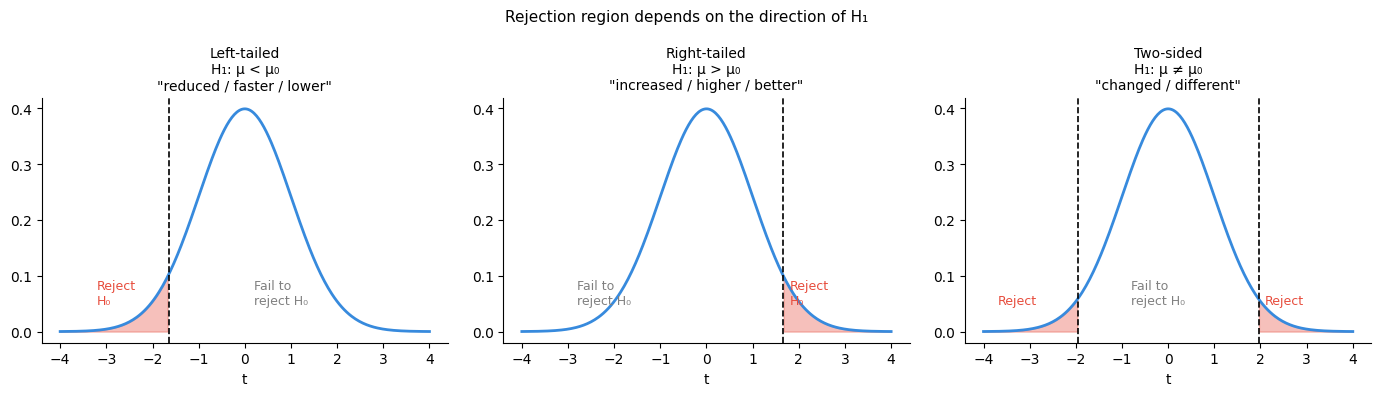

Key takeaway:
  Left-tailed  → large NEGATIVE t rejects H₀  (something got lower)
  Right-tailed → large POSITIVE t rejects H₀  (something got higher)
  Two-sided    → extreme t in EITHER direction rejects H₀


In [3]:
# Three distributions — same curve, different rejection regions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x = np.linspace(-4, 4, 300)
y = stats.norm.pdf(x)

titles = [
    'Left-tailed\nH₁: μ < μ₀\n"reduced / faster / lower"',
    'Right-tailed\nH₁: μ > μ₀\n"increased / higher / better"',
    'Two-sided\nH₁: μ ≠ μ₀\n"changed / different"'
]

for ax, title in zip(axes, titles):
    ax.plot(x, y, color='#378ADD', linewidth=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Left-tailed: rejection in the left tail
axes[0].fill_between(x, y, where=(x <= -1.65), alpha=0.35, color='#e74c3c')
axes[0].axvline(-1.65, color='black', linestyle='--', linewidth=1.2)
axes[0].text(-3.2, 0.05, 'Reject\nH₀',        color='#e74c3c', fontsize=9)
axes[0].text( 0.2, 0.05, 'Fail to\nreject H₀', color='gray',   fontsize=9)

# Right-tailed: rejection in the right tail
axes[1].fill_between(x, y, where=(x >= 1.65), alpha=0.35, color='#e74c3c')
axes[1].axvline(1.65, color='black', linestyle='--', linewidth=1.2)
axes[1].text(-2.8, 0.05, 'Fail to\nreject H₀', color='gray',   fontsize=9)
axes[1].text( 1.8, 0.05, 'Reject\nH₀',         color='#e74c3c', fontsize=9)

# Two-sided: rejection in both tails
axes[2].fill_between(x, y, where=(x <= -1.96), alpha=0.35, color='#e74c3c')
axes[2].fill_between(x, y, where=(x >=  1.96), alpha=0.35, color='#e74c3c')
axes[2].axvline(-1.96, color='black', linestyle='--', linewidth=1.2)
axes[2].axvline( 1.96, color='black', linestyle='--', linewidth=1.2)
axes[2].text(-3.7, 0.05, 'Reject', color='#e74c3c', fontsize=9)
axes[2].text( 2.1, 0.05, 'Reject', color='#e74c3c', fontsize=9)
axes[2].text(-0.8, 0.05, 'Fail to\nreject H₀', color='gray', fontsize=9)

plt.suptitle('Rejection region depends on the direction of H₁', fontsize=11)
plt.tight_layout()
plt.show()

print('Key takeaway:')
print('  Left-tailed  → large NEGATIVE t rejects H₀  (something got lower)')
print('  Right-tailed → large POSITIVE t rejects H₀  (something got higher)')
print('  Two-sided    → extreme t in EITHER direction rejects H₀')

---
## Part 4 — Real World Example: COVID Test and Alpha

During the pandemic, different tests were built with different α levels:

| Test | α | Priority |
|------|---|----------|
| PCR (lab) | very low (≈0.01) | Almost no false positives — slow but precise |
| Rapid antigen | higher (≈0.10) | Fast and accessible — catches more real cases but more false alarms |

The same dataset. Different α. Different outcomes.

- **H₀:** the person is healthy
- **H₁:** the person is infected
- **Type I error (α):** calling a healthy person positive — false alarm
- **Type II error (β):** missing a real infection — false negative

In [4]:
# Simulate a population of 200 people — 50 infected, 150 healthy
np.random.seed(42)

n_infected = 50
n_healthy  = 150

# Viral load scores — infected people score higher on average
scores_infected = np.random.normal(loc=6.0, scale=1.5, size=n_infected)
scores_healthy  = np.random.normal(loc=3.5, scale=1.5, size=n_healthy)

all_scores  = np.concatenate([scores_infected, scores_healthy])
true_status = np.array(['infected'] * n_infected + ['healthy'] * n_healthy)

print(f'Total people tested : {len(all_scores)}')
print(f'Truly infected      : {n_infected}')
print(f'Truly healthy       : {n_healthy}')

Total people tested : 200
Truly infected      : 50
Truly healthy       : 150


In [5]:
# Compute threshold for each alpha
# Lower alpha = stricter threshold = fewer positives called

mean_healthy = scores_healthy.mean()
std_healthy  = scores_healthy.std()

alphas     = [0.01, 0.05, 0.10]
thresholds = [stats.norm.ppf(1 - a, loc=mean_healthy, scale=std_healthy)
              for a in alphas]

print(f'{"α":<8} {"Threshold":<12} Meaning')
print('-' * 55)
for a, t in zip(alphas, thresholds):
    print(f'{a:<8} {t:<12.2f} score must exceed {t:.2f} to be called positive')

α        Threshold    Meaning
-------------------------------------------------------
0.01     6.75         score must exceed 6.75 to be called positive
0.05     5.81         score must exceed 5.81 to be called positive
0.1      5.30         score must exceed 5.30 to be called positive


In [6]:
# Count outcomes at each threshold
print(f'{"α":<6} {"Threshold":<11} {"True Pos":>10} {"False Pos":>11} {"True Neg":>10} {"False Neg":>11}')
print('-' * 62)

for a, threshold in zip(alphas, thresholds):
    predicted_positive = all_scores > threshold

    true_pos  = sum(( predicted_positive) & (true_status == 'infected'))
    false_pos = sum(( predicted_positive) & (true_status == 'healthy'))
    true_neg  = sum((~predicted_positive) & (true_status == 'healthy'))
    false_neg = sum((~predicted_positive) & (true_status == 'infected'))

    print(f'{a:<6} {threshold:<11.2f} {true_pos:>10} {false_pos:>11} {true_neg:>10} {false_neg:>11}')

α      Threshold     True Pos   False Pos   True Neg   False Neg
--------------------------------------------------------------
0.01   6.75                10           3        147          40
0.05   5.81                22           9        141          28
0.1    5.30                30          14        136          20


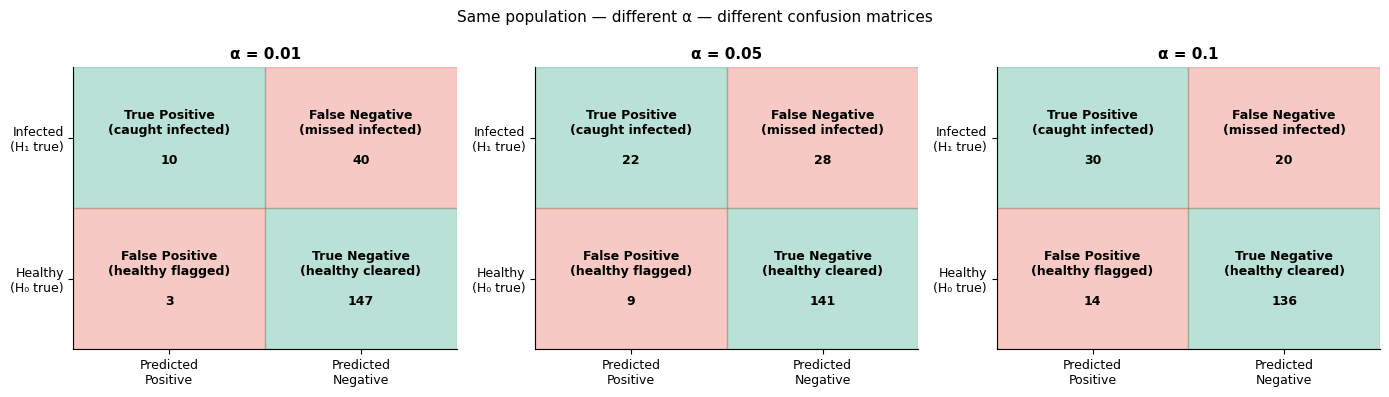

In [8]:
# Visualise — confusion matrix for each alpha
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, a, threshold in zip(axes, alphas, thresholds):
    predicted_positive = all_scores > threshold

    tp = sum(( predicted_positive) & (true_status == 'infected'))
    fp = sum(( predicted_positive) & (true_status == 'healthy'))
    tn = sum((~predicted_positive) & (true_status == 'healthy'))
    fn = sum((~predicted_positive) & (true_status == 'infected'))

    matrix = [[tp, fn],
              [fp, tn]]

    labels = [['True Positive\n(caught infected)', 'False Negative\n(missed infected)'],
              ['False Positive\n(healthy flagged)', 'True Negative\n(healthy cleared)']]

    colors = [['#1D9E75', '#e74c3c'],
              ['#e74c3c', '#1D9E75']]

    for row in range(2):
        for col in range(2):
            ax.add_patch(plt.Rectangle((col, 1 - row), 1, 1,
                         color=colors[row][col], alpha=0.3))
            ax.text(col + 0.5, 1.5 - row,
                    f'{labels[row][col]}\n\n{matrix[row][col]}',
                    ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Predicted\nPositive', 'Predicted\nNegative'], fontsize=9)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Healthy\n(H₀ true)', 'Infected\n(H₁ true)'], fontsize=9)
    ax.set_title(f'α = {a}', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Same population — different α — different confusion matrices', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
print('Which α is best for a COVID screening test?')
print()
print('  α = 0.01  → catches fewer infected people (high false negatives)')
print('             → DANGEROUS in a pandemic — infected people walk free')
print()
print('  α = 0.05  → middle ground — still misses some real cases')
print()
print('  α = 0.10  → catches the most infected people (low false negatives)')
print('             → some healthy people flagged, but they just isolate')
print('             → BEST CHOICE here — the cost of missing is far higher')
print()
print('Rule: when missing a real effect is dangerous → use higher α')
print('      when false alarms are costly            → use lower α')

Which α is best for a COVID screening test?

  α = 0.01  → catches fewer infected people (high false negatives)
             → DANGEROUS in a pandemic — infected people walk free

  α = 0.05  → middle ground — still misses some real cases

  α = 0.10  → catches the most infected people (low false negatives)
             → some healthy people flagged, but they just isolate
             → BEST CHOICE here — the cost of missing is far higher

Rule: when missing a real effect is dangerous → use higher α
      when false alarms are costly            → use lower α


---
## Part 5 — The 8-Step Procedure

Every hypothesis test follows the same 8 steps.
We work through them one by one using the onboarding example from the slides.

**Situation:**  
We want to test whether a new onboarding flow reduces the average onboarding time
below the previous benchmark of 5 minutes.

```
Step 1 — Define the business and statistical question
Step 2 — Write H₀ and H₁
Step 3 — Choose confidence level (α)
Step 4 — Collect data and compute sample statistics
Step 5 — Calculate the test statistic
Step 6 — Find the critical value
Step 7 — Calculate the p-value
Step 8 — Business conclusion
```

In [11]:
# Step 1 — Define the question and create the dataset
#
# Business: Is the new onboarding flow faster than the old benchmark of 5 minutes?
# Statistics: Is the true mean onboarding time lower than 5?
#
# We simulate 10 users and store the data in a small pandas DataFrame
# so it looks like a real dataset you would load from a database.

import pandas as pd
np.random.seed(42)

times = np.random.normal(loc=4.79, scale=0.20, size=10).round(1)

onboarding_df = pd.DataFrame({
    'user_id'         : range(1, 11),
    'onboarding_time' : times
})

print('Onboarding dataset:')
print(onboarding_df.to_string(index=False))


Simulated onboarding times (minutes):
[4.9 4.8 4.9 5.1 4.7 4.7 5.1 4.9 4.7 4.9]

These represent 10 users who went through the new flow.
Each value is one user's time — it varies because people are different.


In [ ]:
# Now calculate the key statistics directly from the column
# This is exactly what you would do with a real dataset

onboarding_times = onboarding_df['onboarding_time']

x_bar    = onboarding_times.mean()
s        = onboarding_times.std()       # pandas uses ddof=1 by default
variance = onboarding_times.var()       # variance = std²
n        = len(onboarding_times)

print(f'Mean     (x̄) : {x_bar:.4f} minutes')
print(f'Std dev  (s)  : {s:.4f} minutes')
print(f'Variance (s²) : {variance:.4f}')
print(f'Sample size   : {n}')
print()
print(f'The average onboarding time is {x_bar:.1f} min — below the benchmark of 5 min.')
print(f'But is this difference real or just random variation? That is what the test decides.')


In [ ]:
# Step 2 — Write the hypotheses
# Direction: we expect the new flow to be FASTER (lower time) → left-tailed
#
# H₀: μ ≥ 5   (onboarding time is still at least 5 minutes — nothing improved)
# H₁: μ < 5   (onboarding time dropped — improvement detected)

mu_0 = ___   # fill in: the benchmark value from the situation
print(f'Benchmark (μ₀) : {mu_0} minutes')
print('H₀: μ >= 5  (no improvement)')
print('H₁: μ < 5   (improvement detected)')



In [ ]:
# Step 3 — Choose confidence level
# We accept a 5% risk of saying the new flow is faster when it actually is not.

alpha      = ___         
confidence = 1 - alpha

print(f'α (significance level) : {alpha}')
print(f'Confidence level       : {confidence}')



In [ ]:
# Step 4 — Compute sample statistics
# x_bar = sample mean
# s     = sample standard deviation  (ddof=1 for sample, not population) 
# n     = sample size      # len() gives the number of elements in the array

x_bar = np.___(onboarding_times)           
s     = np.___(onboarding_times, ddof=1)   
n     = ________(onboarding_times)         

print(f'Sample mean (x̄) : {x_bar:.4f}')
print(f'Sample std  (s)  : {s:.4f}')
print(f'Sample size (n)  : {n}')



---
### Understanding the t-statistic

Before computing it, let's understand what it means.

**The t-statistic answers:**
> How far is my sample mean from the benchmark, measured in standard errors?

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

| Piece | What it means |
|-------|---------------|
| $\bar{x} - \mu_0$ | Distance between your sample mean and the benchmark |
| $s / \sqrt{n}$ | Standard error — how much your mean naturally varies by chance |
| $t$ | Distance expressed in units of natural variation |

**How to read the result:**

| t value | Meaning |
|---------|---------|
| t = 0 | Sample mean is exactly at the benchmark — no evidence against H₀ |
| t = −1 | Sample mean is 1 standard error below the benchmark — weak evidence |
| t = −3 | Sample mean is 3 standard errors below the benchmark — strong evidence |

The further t is from 0 (in the direction of H₁), the stronger the evidence against H₀.

---

### Understanding the critical value

The **critical value** (t_critical) is the threshold your t-statistic must cross to reject H₀.

It is determined by α and degrees of freedom — not by your data.

```
Left-tailed test:

     reject H₀         |    fail to reject H₀
─────────────────────── | ────────────────────────────
                   t_critical                    0

If t_statistic < t_critical  →  reject H₀
If t_statistic > t_critical  →  fail to reject H₀
```

**Concrete example:**
```
t_statistic = −3.37   (our sample mean is well below the benchmark)
t_critical  = −1.83   (the boundary at α = 0.05)

Is −3.37 < −1.83?   YES  →  reject H₀
```

Think of t_critical as a **speed limit**.  
If your t_statistic exceeds it in the direction of H₁ — you get caught.  
That means your result is statistically significant.


In [ ]:
# Step 5 — Calculate the test statistic
#
# Formula:  t = (x̄ - μ₀) / (s / √n)
#
# Intuition: how many standard errors is our sample mean away from the benchmark?
# Very negative t → our mean is well below μ₀ → strong evidence for H₁

standard_error = s / np.sqrt(n)


print(f'Standard error : {standard_error:.4f}')

t_statistic = (___ - ___) / ___   # fill in: x_bar, mu_0, standard_error



print(f't-statistic    : {t_statistic:.4f}')
print()
print('Negative t → sample mean is BELOW the benchmark → evidence for H₁')



In [ ]:
# Step 6 — Find the critical value
# For a one-sided LEFT test: reject H₀ if t < t_critical
# Degrees of freedom = n - 1

df         = n - ___                      # fill in: 1
t_critical = stats.t.ppf(___, ___)        # fill in: alpha, df

print(f'Degrees of freedom : {df}')
print(f'Critical value     : {t_critical:.4f}')
print()
print(f'Rule: reject H₀ if t_statistic < t_critical')
print(f'      {t_statistic:.4f} < {t_critical:.4f} → {t_statistic < t_critical}')



In [ ]:
# Visualise — where does our t-statistic land on the distribution?
x = np.linspace(-5, 5, 300)
y = stats.t.pdf(x, df)

plt.figure(figsize=(9, 4))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x <= t_critical),
                 alpha=0.3, color='#e74c3c', label=f'Rejection region (α={alpha})')
plt.axvline(t_statistic, color='#e74c3c', linewidth=2,
            linestyle='--', label=f't-statistic = {t_statistic:.2f}')
plt.axvline(t_critical, color='black', linewidth=1.5,
            linestyle=':', label=f'Critical value = {t_critical:.2f}')
plt.xlabel('t')
plt.ylabel('Density')
plt.title(f't-distribution (df={df}) — one-sided left test')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
### The decision rule — two equivalent ways

After computing the test statistic, you have two ways to make the decision.  
**Both always give the same answer.**

**Method 1 — Compare t-statistic to critical value**

| Test direction | Reject H₀ if |
|---------------|---------------|
| Left-tailed  | t_statistic **<** t_critical |
| Right-tailed | t_statistic **>** t_critical |
| Two-sided    | \|t_statistic\| **>** \|t_critical\| |

This is visual — you can see on the distribution curve whether your t landed in the red zone.

---

**Method 2 — Compare p-value to α**

```
Always, for any test:   reject H₀ if  p-value < α
```

The p-value is the probability of seeing your result (or more extreme) **if H₀ were true**.  
If that probability is smaller than your tolerance (α) → your result is too surprising → reject H₀.

| p-value | Interpretation |
|---------|----------------|
| p = 0.004 | If H₀ were true, only 0.4% chance of seeing this → very surprising → reject H₀ |
| p = 0.30 | If H₀ were true, 30% chance of seeing this → not surprising at all → fail to reject H₀ |

> **In practice:** most people use p-value < α because it is one rule that works for all test types.  
> The critical value method is useful for understanding what is happening visually.


In [ ]:
# Step 7 — Calculate the p-value
#
# p-value = P(seeing a result this extreme or more | H₀ is true)
# For a left-tailed test: p-value = P(T ≤ t_statistic) = stats.t.cdf(t_statistic, df)
# Rule: reject H₀ if p-value < α

p_value = stats.t.cdf(___, ___)   # fill in: t_statistic, df

print(f'p-value  : {p_value:.4f}')
print(f'α        : {alpha}')
print()
print(f'p < α    : {p_value < alpha}')
print(f'Reject H₀: {p_value < alpha}')





# ANSWER: stats.t.cdf(t_statistic, df)

In [ ]:
# Step 8 — Business conclusion
# Always translate the statistical result back into business language

print('=' * 55)
print('BUSINESS CONCLUSION')
print('=' * 55)
print()

if p_value < alpha:
    print('Decision   : REJECT H₀')
    print('Statistical: Result is significant at the 5% level.')
    print('Business   : Evidence is strong enough to conclude that')
    print('             onboarding time decreased below 5 minutes.')
else:
    print('Decision   : FAIL TO REJECT H₀')
    print('Statistical: Result is NOT significant at the 5% level.')
    print('Business   : Not enough evidence that the new flow is faster.')

### Shortcut — scipy does steps 5 to 7 in one line

Once you understand the manual steps, scipy can do it all at once:

```python
# alternative: 'less' = left-tailed, 'greater' = right-tailed, 'two-sided'
t_stat, p_val = stats.ttest_1samp(data, popmean=μ₀, alternative='less')
```

In [ ]:
# Verify our manual calculation using scipy
t_auto, p_auto = stats.ttest_1samp(onboarding_times, popmean=mu_0, alternative='less')

print('Scipy result:')
print(f'  t-statistic : {t_auto:.4f}')
print(f'  p-value     : {p_auto:.4f}')
print()
print('Manual result:')
print(f'  t-statistic : {t_statistic:.4f}')
print(f'  p-value     : {p_value:.4f}')
print()
print(f'Match: {abs(t_auto - t_statistic) < 1e-10}')

---
## Part 6 — Practice Exercises

### Exercise 2 — SumUp (one-sample mean, left-tailed)

**Business question:**  
Does offering a faster card-reader setup tutorial reduce the average time merchants
need to complete device activation?

Old benchmark: 8 minutes. We simulate data from 12 merchants using the new tutorial.

In [ ]:
# Create the dataset — merchants using the new setup tutorial
import pandas as pd
np.random.seed(7)

times = np.random.normal(loc=7.3, scale=0.4, size=12).round(1)

activation_df = pd.DataFrame({
    'merchant_id'     : range(1, 13),
    'tutorial'        : ['new'] * 12,
    'activation_time' : times
})

benchmark = 8.0

print('Activation time dataset:')
print(activation_df.to_string(index=False))


In [ ]:
# Calculate key statistics from the column
activation_times = activation_df['activation_time']

x_bar    = activation_times.mean()
s        = activation_times.std()
variance = activation_times.var()
n        = len(activation_times)

print(f'Mean     (x̄) : {x_bar:.4f} minutes')
print(f'Std dev  (s)  : {s:.4f} minutes')
print(f'Variance (s²) : {variance:.4f}')
print(f'Sample size   : {n}')
print()
print(f'Benchmark     : {benchmark} minutes')
print(f'Difference    : {x_bar - benchmark:.4f} minutes')
print()
print(f'The average is below the benchmark — but is the difference real or just noise?')


In [ ]:
# Step 1 — Sample statistics
x_bar = np.___(activation_times)           # fill in
s     = np.___(activation_times, ddof=1)   # fill in
n     = len(activation_times)

print(f'Sample mean : {x_bar:.4f}')
print(f'Sample std  : {s:.4f}')
print(f'Sample size : {n}')

# ANSWER: np.mean() / np.std()

In [ ]:
# Step 2 — Hypotheses
# H₀: μ ___ 8   (fill in the direction)
# H₁: μ ___ 8

# Step 3 — Alpha
alpha = ___   # fill in: 0.05

# Step 4 — t-statistic
se     = s / np.sqrt(n)
t_stat = (x_bar - ___) / se   # fill in: benchmark
print(f't-statistic: {t_stat:.4f}')

# ANSWER: alpha=0.05  /  t_stat = (x_bar - benchmark) / se

In [ ]:
# Step 5 — p-value using scipy
# hint: alternative='less' because we expect LOWER activation time

_, p_val = stats.ttest_1samp(activation_times, popmean=___, alternative='___')

print(f'p-value  : {p_val:.4f}')
print(f'α        : {alpha}')
print(f'Reject H₀: {p_val < alpha}')

# ANSWER: popmean=benchmark, alternative='less'

In [ ]:
# Step 6 — Business conclusion
if p_val < alpha:
    print('Reject H₀ — the new tutorial significantly reduces activation time.')
else:
    print('Fail to reject H₀ — not enough evidence that the tutorial is faster.')

### Exercise 3 — GetYourGuide (two-sample, two-sided)

**Business question:**  
Does adding more customer reviews to tour pages **change** the average booking conversion rate?

Two groups: Control (original page) and Treatment (with more reviews).

In [ ]:
# Create the dataset — a realistic A/B test table
# Each row is one user: which group they were in and whether they converted
import pandas as pd
np.random.seed(99)

n_per_group = 10

# Control group — original page
control_converted   = np.random.binomial(1, p=0.13, size=n_per_group)

# Treatment group — page with more reviews
treatment_converted = np.random.binomial(1, p=0.16, size=n_per_group)

ab_test = pd.DataFrame({
    'user_id'   : range(1, n_per_group * 2 + 1),
    'group'     : ['control'] * n_per_group + ['treatment'] * n_per_group,
    'converted' : list(control_converted) + list(treatment_converted)
})

print('A/B test dataset:')
print(ab_test.to_string(index=False))


In [ ]:
# Calculate conversion rate per group from the table
# conversion rate = number of conversions / total users in that group

control_data   = ab_test[ab_test['group'] == 'control']['converted']
treatment_data = ab_test[ab_test['group'] == 'treatment']['converted']

mean_control   = control_data.mean()
mean_treatment = treatment_data.mean()

print(f'Control   — users: {len(control_data)}  conversions: {control_data.sum()}  rate: {mean_control:.3f}')
print(f'Treatment — users: {len(treatment_data)}  conversions: {treatment_data.sum()}  rate: {mean_treatment:.3f}')
print()
print(f'Difference : {mean_treatment - mean_control:.3f}')
print(f'Is this difference real or just random variation? That is what the test decides.')


In [ ]:
# Step 1 — Sample statistics
mean_control   = np.___(control)     # fill in
mean_treatment = np.___(treatment)   # fill in

print(f'Control mean   : {mean_control:.4f}')
print(f'Treatment mean : {mean_treatment:.4f}')
print(f'Difference     : {mean_treatment - mean_control:.4f}')

# ANSWER: np.mean()

In [ ]:
# Step 2 — Hypotheses (two-sided: we expect CHANGE, not a specific direction)
# H₀: μ_T = μ_C
# H₁: μ_T ≠ μ_C

alpha = 0.05

# Step 3 — Two-sample t-test
# hint: alternative='two-sided' since we only care IF there is a difference
t_stat, p_val = stats.ttest_ind(treatment, control, alternative='___')

print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.4f}')
print(f'Reject H₀   : {p_val < alpha}')

# ANSWER: alternative='two-sided'

In [ ]:
# Step 4 — Business conclusion
if p_val < alpha:
    print('Adding more reviews significantly changes the conversion rate.')
    if mean_treatment > mean_control:
        print('The change is POSITIVE — treatment has higher conversion.')
    else:
        print('The change is NEGATIVE — treatment has lower conversion.')
else:
    print('No significant difference detected between the two page versions.')

---
## Quick Reference

```python
from scipy import stats
import numpy as np

# ── Key formulas ──────────────────────────────────────────────────────────────
confidence = 1 - alpha                          # 1 - Type I error
power      = 1 - beta                           # 1 - Type II error

x_bar = np.mean(data)                           # sample mean
s     = np.std(data, ddof=1)                    # sample std
se    = s / np.sqrt(n)                          # standard error
t     = (x_bar - mu_0) / se                     # t-statistic
df    = n - 1                                   # degrees of freedom

t_critical = stats.t.ppf(alpha, df)             # critical value (left-tailed)
p_value    = stats.t.cdf(t_stat, df)            # p-value (left-tailed)

# ── scipy shortcuts ───────────────────────────────────────────────────────────
stats.ttest_1samp(data, popmean=mu_0, alternative='less')      # left-tailed
stats.ttest_1samp(data, popmean=mu_0, alternative='greater')   # right-tailed
stats.ttest_1samp(data, popmean=mu_0, alternative='two-sided') # two-sided
stats.ttest_ind(treatment, control,   alternative='two-sided') # two groups

# ── Decision rule ─────────────────────────────────────────────────────────────
# Reject H₀ if p_value < alpha

# ── Direction cheat sheet ─────────────────────────────────────────────────────
# 'less'      → H₁: μ < μ₀  — "reduced", "faster", "lower"
# 'greater'   → H₁: μ > μ₀  — "increased", "higher", "better"
# 'two-sided' → H₁: μ ≠ μ₀  — "changed", "different", "affected"
```